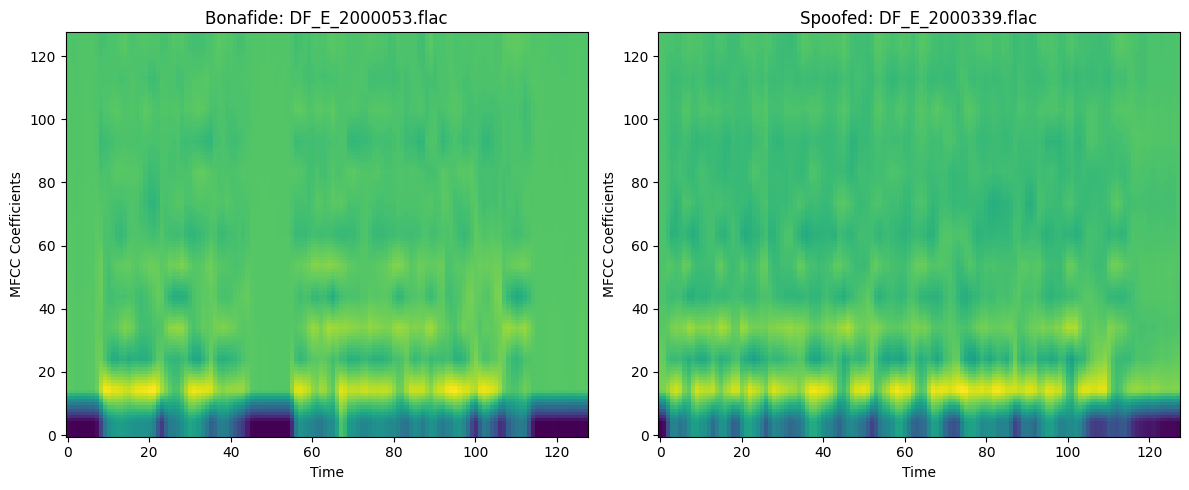

In [1]:
import os
import glob
import numpy as np
import librosa
import cv2
import matplotlib.pyplot as plt

# Load metadata and audio files
metadata_file_path = r'D:\download\Compressed\DF-keys-full\keys\DF\CM\trial_metadata.txt'
undersampled_audio_dir = r'D:\audio_files\undersampled_audio'

# Dictionary to hold file identifiers and labels
labels = {}

# Read the metadata file and store labels
with open(metadata_file_path, 'r') as f:
    for line in f:
        parts = line.strip().split()
        file_identifier = parts[1]  # Example: DF_E_2000011
        label = parts[5]            # Example: "spoof"
        labels[file_identifier] = label

# Find all .flac files in the undersampled directory
audio_files = glob.glob(os.path.join(undersampled_audio_dir, '*.flac'))

# Filter valid audio files based on metadata labels
valid_audio_files = []
valid_labels = []

for audio_file in audio_files:
    file_name = os.path.basename(audio_file)
    file_identifier = file_name.split('.')[0]  # Extract the file identifier (before the extension)

    # Check if the file identifier exists in the metadata labels
    if file_identifier in labels:
        valid_audio_files.append(audio_file)
        valid_labels.append(1 if labels[file_identifier] == 'spoof' else 0)  # Binary label (1: spoof, 0: bonafide)

# extract MFCC
def audio_to_mfcc(audio_file, sr=22050, n_mfcc=13):
    """Convert audio to MFCC."""
    audio, sample_rate = librosa.load(audio_file, sr=sr)
    mfcc = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=n_mfcc)
    return mfcc

def resize_spectrogram(spectrogram, target_size=(128, 128)):
    """Resize the MFCC to a fixed size."""
    return cv2.resize(spectrogram, target_size)

# One bonafide and one spoofed audio file
bonafide_index = valid_labels.index(0)  # Find the first bonafide sample
spoof_index = valid_labels.index(1)     # Find the first spoofed sample

# File names for bonafide and spoofed files
bonafide_file_name = os.path.basename(valid_audio_files[bonafide_index])
spoof_file_name = os.path.basename(valid_audio_files[spoof_index])

# MFCCs of chosen audio files
bonafide_mfcc = audio_to_mfcc(valid_audio_files[bonafide_index])
spoof_mfcc = audio_to_mfcc(valid_audio_files[spoof_index])
bonafide_mfcc_resized = resize_spectrogram(bonafide_mfcc, target_size=(128, 128))
spoof_mfcc_resized = resize_spectrogram(spoof_mfcc, target_size=(128, 128))

# Plot MFCCs side by side with file names as titles
def plot_mfcc(mfcc, title, ax):
    """Plot MFCC with a given title on a specific axis."""
    ax.imshow(mfcc, cmap='viridis', origin='lower', aspect='auto')
    ax.set_title(title)
    ax.set_xlabel('Time')
    ax.set_ylabel('MFCC Coefficients')

# Create a side-by-side plot
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot bonafide MFCC with file name
plot_mfcc(bonafide_mfcc_resized, f"Bonafide: {bonafide_file_name}", axs[0])

# Plot spoofed MFCC with file name
plot_mfcc(spoof_mfcc_resized, f"Spoofed: {spoof_file_name}", axs[1])

# Show the plots
plt.tight_layout()
plt.show()


In [2]:
from IPython.display import Audio, display

# Load the bonafide or spoofed audio file
def play_audio(file_path):
    """Load and play the selected audio file."""
    audio_data, sample_rate = librosa.load(file_path, sr=None)
    display(Audio(audio_data, rate=sample_rate))


print(f"Playing Bonafide file: {bonafide_file_name}")
play_audio(valid_audio_files[bonafide_index])

print(f"Playing Spoofed file: {spoof_file_name}")
play_audio(valid_audio_files[spoof_index])


Playing Bonafide file: DF_E_2000053.flac


Playing Spoofed file: DF_E_2000339.flac


In [3]:
# extract Mel-spectrogram
#n_mels=mel bands
def audio_to_melspectrogram(audio_file, sr=22050, n_mels=128):
    audio, sample_rate = librosa.load(audio_file, sr=sr)
    mel_spectrogram = librosa.feature.melspectrogram(y=audio, sr=sample_rate, n_mels=n_mels)
    mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)  # Convert to dB
    return mel_spectrogram_db

def resize_spectrogram(spectrogram, target_size=(128, 128)):
    return cv2.resize(spectrogram, target_size)

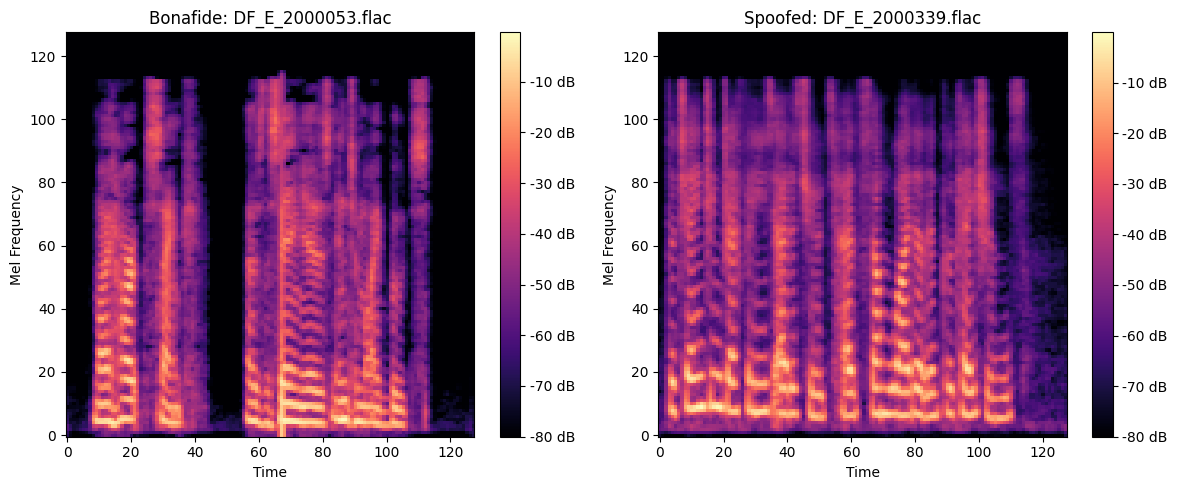

Playing Bonafide file: DF_E_2000053.flac


Playing Spoofed file: DF_E_2000339.flac


In [4]:


# Get the file names for bonafide and spoofed files
bonafide_file_name = os.path.basename(valid_audio_files[bonafide_index])
spoof_file_name = os.path.basename(valid_audio_files[spoof_index])

# get their Mel-spectrograms
bonafide_melspectrogram = audio_to_melspectrogram(valid_audio_files[bonafide_index])
spoof_melspectrogram = audio_to_melspectrogram(valid_audio_files[spoof_index])

# Resize the Mel-spectrograms to one size
bonafide_melspectrogram_resized = resize_spectrogram(bonafide_melspectrogram, target_size=(128, 128))
spoof_melspectrogram_resized = resize_spectrogram(spoof_melspectrogram, target_size=(128, 128))

# Plot Mel-spectrograms 
def plot_melspectrogram(melspectrogram, title, ax):
    img = ax.imshow(melspectrogram, cmap='magma', origin='lower', aspect='auto')
    ax.set_title(title)
    ax.set_xlabel('Time')
    ax.set_ylabel('Mel Frequency')
    fig.colorbar(img, ax=ax, format="%+2.0f dB")  # Add colorbar

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot bonafide and spoofed Mel-spectrogram with file name
plot_melspectrogram(bonafide_melspectrogram_resized, f"Bonafide: {bonafide_file_name}", axs[0])
plot_melspectrogram(spoof_melspectrogram_resized, f"Spoofed: {spoof_file_name}", axs[1])
plt.tight_layout()
plt.show()

# Load the bonafide or spoofed audio file
def play_audio(file_path):
    audio_data, sample_rate = librosa.load(file_path, sr=None)
    display(Audio(audio_data, rate=sample_rate))

print(f"Playing Bonafide file: {bonafide_file_name}")
play_audio(valid_audio_files[bonafide_index])

# If you want to play the spoofed audio, uncomment the line below:
print(f"Playing Spoofed file: {spoof_file_name}")
play_audio(valid_audio_files[spoof_index])

In [ ]:
# CQCC
# STFT

